In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [3]:
df = pd.read_csv(path+"/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [4]:
print("Shape :", df.shape)

df.info()

df.describe()

df.describe(include="object")

Shape : (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [5]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [6]:
(df.isnull().sum()/len(df))*100

,0
customerID,0.0
gender,0.0
SeniorCitizen,0.0
Partner,0.0
Dependents,0.0
tenure,0.0
PhoneService,0.0
MultipleLines,0.0
InternetService,0.0
OnlineSecurity,0.0


In [7]:
print(df.duplicated().sum())

0


In [8]:
for col in df.columns:
    print(col)
    print(df[col].value_counts())
    print("-"*60)

customerID
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64
------------------------------------------------------------
gender
gender
Male      3555
Female    3488
Name: count, dtype: int64
------------------------------------------------------------
SeniorCitizen
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
------------------------------------------------------------
Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64
------------------------------------------------------------
Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
------------------------------------------------------------
tenure
tenure
1     613
72    362
2     238
3     200
4     176
71    170
5     133
7     131
8     123
9     119
70    119
12    117
10    116
6     110
13    109
68    100
1

In [9]:
df['customerID'].info()
df['TotalCharges'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: customerID
Non-Null Count  Dtype 
--------------  ----- 
7043 non-null   object
dtypes: object(1)
memory usage: 55.2+ KB
<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype 
--------------  ----- 
7043 non-null   object
dtypes: object(1)
memory usage: 55.2+ KB


In [10]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


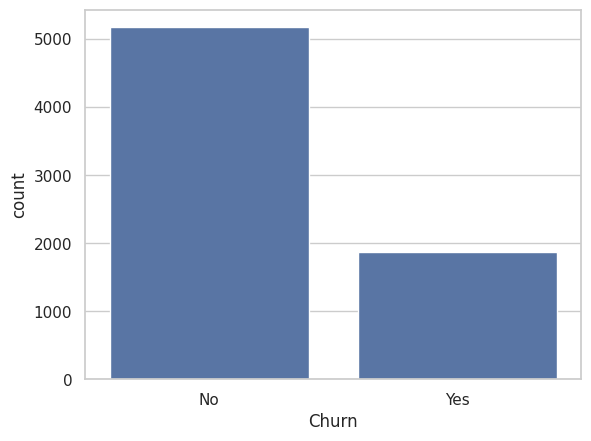

In [11]:
sns.countplot(data=df, x="Churn")
plt.show()

In [12]:
df["Churn"].value_counts(normalize=True)*100

,proportion
Churn,
No,73.463013
Yes,26.536987


<Axes: xlabel='tenure', ylabel='Count'>

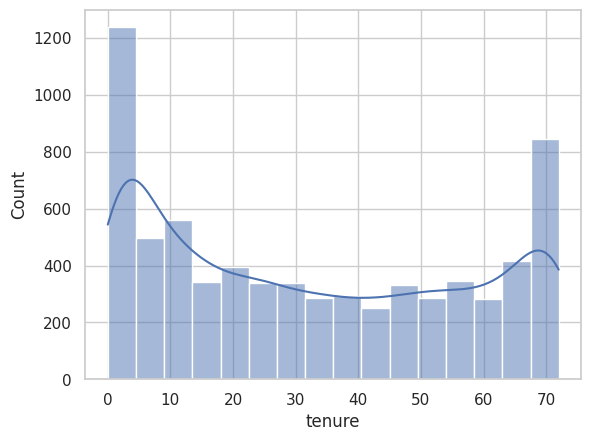

In [13]:
sns.histplot(df["tenure"], kde=True)

<Axes: xlabel='tenure'>

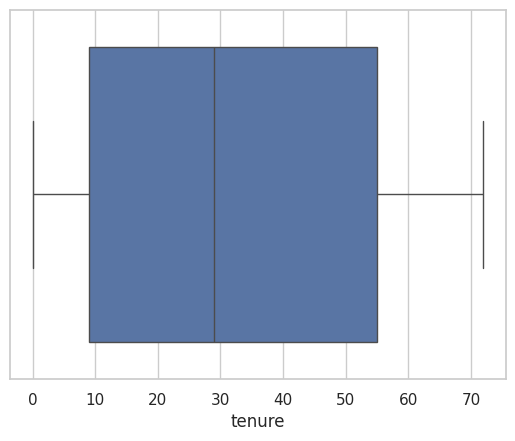

In [14]:
sns.boxplot(x=df["tenure"])

<Axes: xlabel='Contract', ylabel='count'>

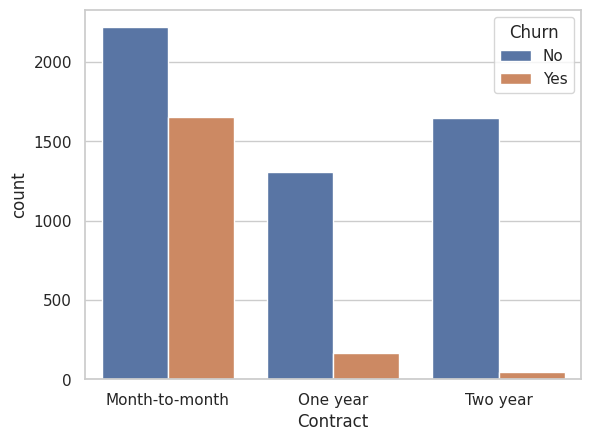

In [15]:
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

In [17]:
pd.crosstab(
    df["Contract"],
    # df[""]
    df["Churn"],
    normalize="index"
)*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


<Axes: >

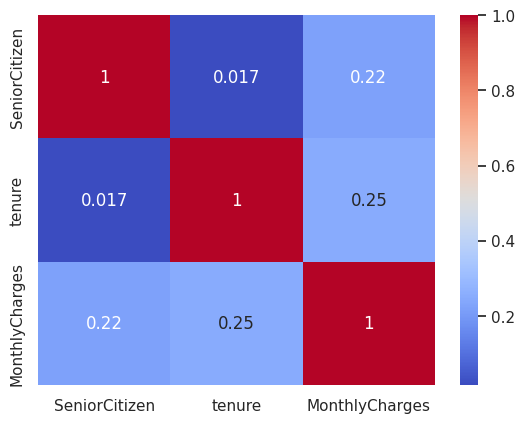

In [18]:
numeric = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges"
]

sns.heatmap(
    df[numeric].corr(),
    annot=True,
    cmap="coolwarm"
)

## Important Matrics

In [19]:
print("Blank values in each column\n")

for col in df.columns:

    blank = (df[col].astype(str).str.strip()=="").sum()

    if blank>0:
        print(f"{col:<20} {blank}")

Blank values in each column

TotalCharges         11


In [20]:
temp = df.copy()

temp["TotalCharges"] = pd.to_numeric(
    temp["TotalCharges"],
    errors="coerce"
)

print(temp["TotalCharges"].isna().sum())

display(
    temp.loc[
        temp["TotalCharges"].isna(),
        ["tenure","MonthlyCharges","TotalCharges","Churn"]
    ]
)

11


,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In [21]:
numeric = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges"
]

display(df[numeric].describe().T)

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


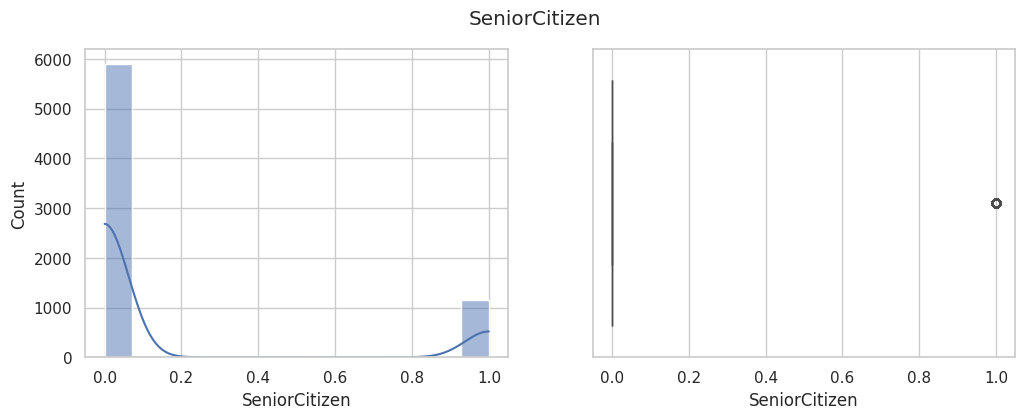

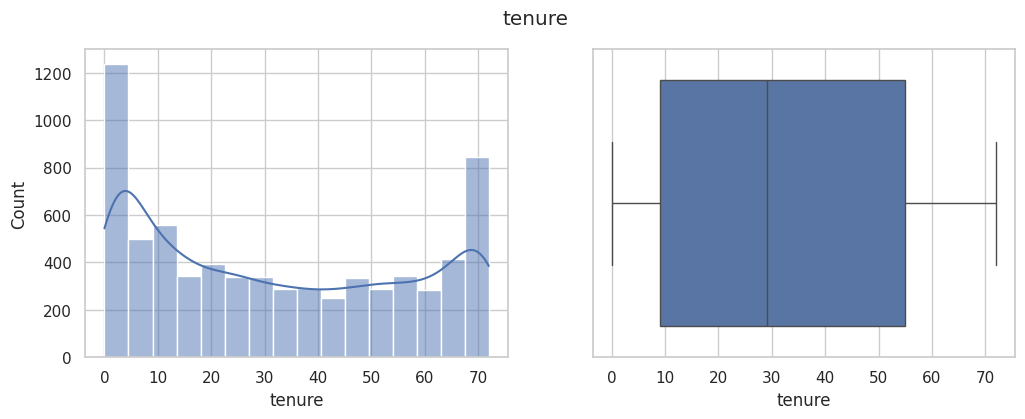

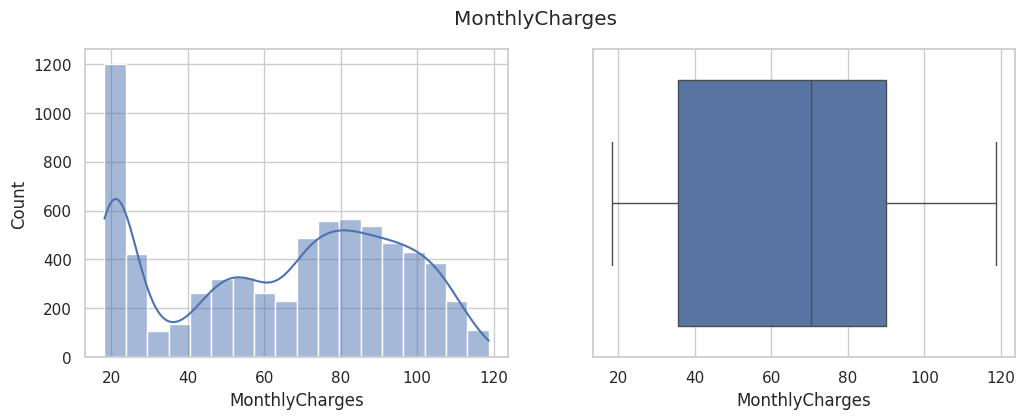

In [22]:
for col in numeric:

    fig,ax=plt.subplots(1,2,figsize=(12,4))

    sns.histplot(df[col],kde=True,ax=ax[0])

    sns.boxplot(x=df[col],ax=ax[1])

    plt.suptitle(col)

    plt.show()

In [23]:
df[numeric].skew()

,0
SeniorCitizen,1.833633
tenure,0.239540
MonthlyCharges,-0.220524


In [24]:
categorical = df.select_dtypes("object").columns

summary=[]

for col in categorical:

    summary.append({
        "Feature":col,
        "Unique":df[col].nunique(),
        "Top":df[col].mode()[0]
    })

pd.DataFrame(summary)

,Feature,Unique,Top
0,customerID,7043,0002-ORFBO
1,gender,2,Male
2,Partner,2,No
3,Dependents,2,No
4,PhoneService,2,Yes
5,MultipleLines,3,No
6,InternetService,3,Fiber optic
7,OnlineSecurity,3,No
8,OnlineBackup,3,No
9,DeviceProtection,3,No


In [25]:
for col in categorical:

    if col=="Churn":
        continue

    print("="*60)
    print(col)
    print("="*60)

    display(
        pd.crosstab(
            df[col],
            df["Churn"],
            normalize="index"
        )*100
    )

customerID


Churn,No,Yes
customerID,,
0002-ORFBO,100.0,0.0
0003-MKNFE,100.0,0.0
0004-TLHLJ,0.0,100.0
0011-IGKFF,0.0,100.0
0013-EXCHZ,0.0,100.0
...,...,...
9987-LUTYD,100.0,0.0
9992-RRAMN,0.0,100.0
9992-UJOEL,100.0,0.0


gender


Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


Partner


...

Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


TotalCharges


Churn,No,Yes
TotalCharges,,
,100.0,0.0
100.2,100.0,0.0
100.25,0.0,100.0
100.35,100.0,0.0
100.4,0.0,100.0
...,...,...
997.75,100.0,0.0
998.1,100.0,0.0
999.45,0.0,100.0


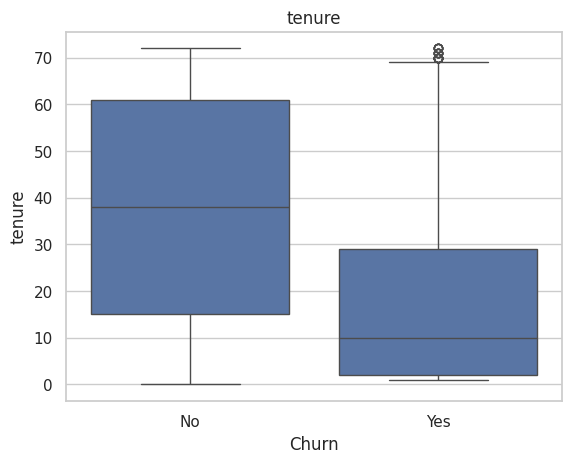

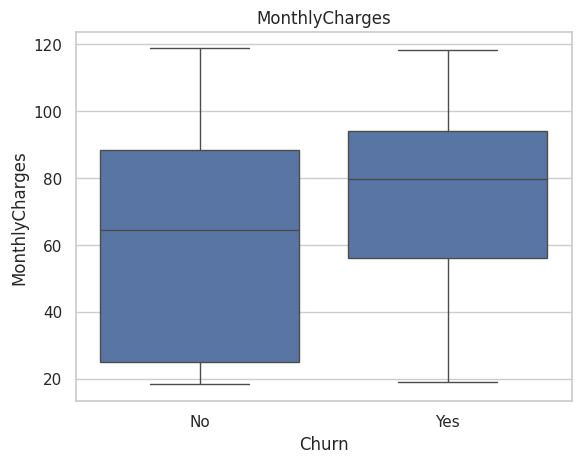

In [26]:
for col in [
    "tenure",
    "MonthlyCharges"
]:

    sns.boxplot(
        data=df,
        x="Churn",
        y=col
    )

    plt.title(col)

    plt.show()

In [27]:
encoding=[]

for col in categorical:

    if col=="customerID":
        continue

    n=df[col].nunique()

    if n==2:
        enc="Label Encoding"

    else:
        enc="One Hot Encoding"

    encoding.append({
        "Feature":col,
        "Unique":n,
        "Suggested Encoding":enc
    })

pd.DataFrame(encoding)

,Feature,Unique,Suggested Encoding
0,gender,2,Label Encoding
1,Partner,2,Label Encoding
2,Dependents,2,Label Encoding
3,PhoneService,2,Label Encoding
4,MultipleLines,3,One Hot Encoding
5,InternetService,3,One Hot Encoding
6,OnlineSecurity,3,One Hot Encoding
7,OnlineBackup,3,One Hot Encoding
8,DeviceProtection,3,One Hot Encoding
9,TechSupport,3,One Hot Encoding


In [28]:
for col in [
    "tenure",
    "MonthlyCharges"
]:

    q1=df[col].quantile(.25)

    q3=df[col].quantile(.75)

    iqr=q3-q1

    lower=q1-1.5*iqr

    upper=q3+1.5*iqr

    out=((df[col]<lower)|(df[col]>upper)).sum()

    print(f"{col} : {out} outliers")

tenure : 0 outliers
MonthlyCharges : 0 outliers


In [29]:
summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Unique Values": df.nunique().values,
    "Missing Values": df.isnull().sum().values,
    "Missing %": ((df.isnull().sum()/len(df))*100).values
})

summary["Category"] = summary["Data Type"].apply(
    lambda x: "Categorical" if x == "object" else "Numerical"
)

display(summary)

,Column,Data Type,Unique Values,Missing Values,Missing %,Category
0,customerID,object,7043,0,0.0,Categorical
1,gender,object,2,0,0.0,Categorical
2,SeniorCitizen,int64,2,0,0.0,Numerical
3,Partner,object,2,0,0.0,Categorical
4,Dependents,object,2,0,0.0,Categorical
5,tenure,int64,73,0,0.0,Numerical
6,PhoneService,object,2,0,0.0,Categorical
7,MultipleLines,object,3,0,0.0,Categorical
8,InternetService,object,3,0,0.0,Categorical
9,OnlineSecurity,object,3,0,0.0,Categorical


In [30]:
df["Churn"].value_counts()

df["Churn"].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


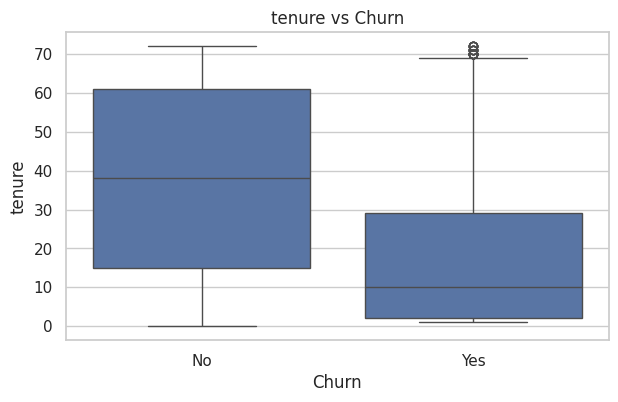

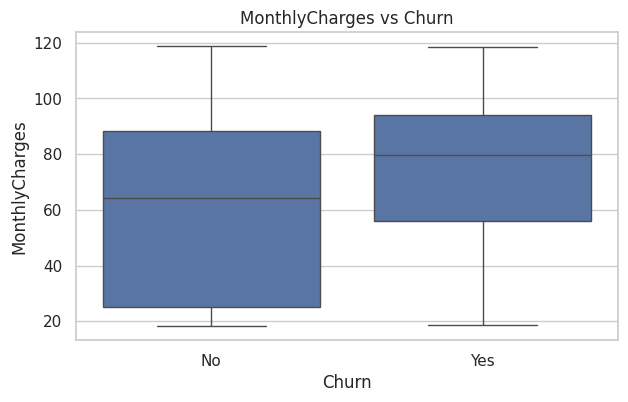

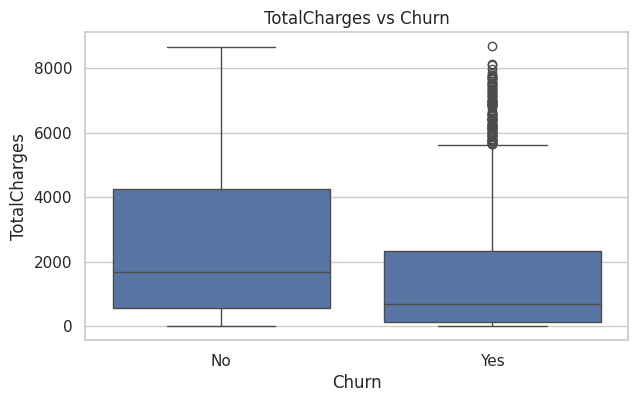

In [31]:
temp = df.copy()

temp["TotalCharges"] = pd.to_numeric(
    temp["TotalCharges"],
    errors="coerce"
)

temp["TotalCharges"] = temp["TotalCharges"].fillna(0)

for col in ["tenure", "MonthlyCharges", "TotalCharges"]:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        data=temp,
        x="Churn",
        y=col
    )

    plt.title(f"{col} vs Churn")

    plt.show()